# RQ2 Lyrics TF-IDF Interpretable Feature Analysis

This notebook inspects the outputs created by `src/05_RQ2_calculate_lyrics_tfidf_interpretable_features.py`.

Focus:
- raw TF-IDF trajectories over time
- genre-level TF-IDF trajectories
- within-period normalized genre positions
- feature and genre candidates for later interpretation

No interpretation is written here yet.

## 1. Setup

Load libraries, locate the project root, and define input/output folders.

In [45]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate

    return start_path


try:
    from helper_functions import PROCESSED_DIR
    PROJECT_ROOT = find_project_root(Path.cwd())
except ImportError:
    PROJECT_ROOT = find_project_root(Path.cwd())
    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RQ2_LYRICS_DIR = PROCESSED_DIR / "RQ2_lyrics_tfidf_interpretable_features"
PLOTS_DIR = PROJECT_ROOT / "plots" / "RQ2_lyrics_tfidf"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED_DIR)
print("Lyrics RQ2 dir:", RQ2_LYRICS_DIR)
print("Plots dir:", PLOTS_DIR)

Project root: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis
Processed dir: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed
Lyrics RQ2 dir: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/RQ2_lyrics_tfidf_interpretable_features
Plots dir: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf


## 2. Load Lyrics TF-IDF Result Tables

Load the calculated tables from the lyrics TF-IDF RQ2 script.

In [46]:
selected_features = pd.read_parquet(
    RQ2_LYRICS_DIR / "lyrics_tfidf_selected_features.parquet"
)

feature_coverage = pd.read_parquet(
    RQ2_LYRICS_DIR / "lyrics_tfidf_feature_coverage.parquet"
)

feature_selection_scores = pd.read_parquet(
    RQ2_LYRICS_DIR / "lyrics_tfidf_feature_selection_scores.parquet"
)

all_genres_window_summary = pd.read_parquet(
    RQ2_LYRICS_DIR / "lyrics_tfidf_all_genres_window_summary.parquet"
)

eligible_genre_window_summary = pd.read_parquet(
    RQ2_LYRICS_DIR / "lyrics_tfidf_eligible_genre_window_summary.parquet"
)

eligible_genre_window_z_summary = pd.read_parquet(
    RQ2_LYRICS_DIR / "lyrics_tfidf_eligible_genre_window_within_period_z_summary.parquet"
)

feature_deviation_summary = pd.read_parquet(
    RQ2_LYRICS_DIR / "lyrics_tfidf_feature_deviation_summary.parquet"
)

all_genres_feature_change = pd.read_parquet(
    RQ2_LYRICS_DIR / "lyrics_tfidf_all_genres_first_last_change.parquet"
)

genre_feature_trends = pd.read_parquet(
    RQ2_LYRICS_DIR / "lyrics_tfidf_genre_feature_trends.parquet"
)

selected_feature_terms = selected_features["feature"].tolist()

selected_terms = selected_features["feature"].tolist()

print(f"Selected lyrics features: {len(selected_feature_terms)}")
print(f"All-genres windows: {all_genres_window_summary.shape}")
print(f"Eligible genre-window rows: {eligible_genre_window_summary.shape}")
print(f"Eligible normalized genre-window rows: {eligible_genre_window_z_summary.shape}")

Selected lyrics features: 40
All-genres windows: (61, 45)
Eligible genre-window rows: (2198, 46)
Eligible normalized genre-window rows: (2198, 46)


## 3. Inspect Selected Lyrics TF-IDF Terms

Overview of the automatically selected terms and their coverage/change scores.

In [47]:
selected_features[
    [
        "selection_rank",
        "feature",
        "n_nonzero_tracks",
        "nonzero_share",
        "mean_tfidf",
        "temporal_std",
        "last_minus_first",
        "linear_trend",
    ]
].sort_values("selection_rank")

,selection_rank,feature,n_nonzero_tracks,nonzero_share,mean_tfidf,temporal_std,last_minus_first,linear_trend
0,1,love,34299,0.350408,0.046203,0.008934,-0.026723,-0.000440
1,2,babi,13113,0.133966,0.019474,0.008657,-0.019128,-0.000439
2,3,want,33190,0.339078,0.038134,0.006058,0.026552,0.000308
3,4,blue,4835,0.049396,0.006501,0.006107,-0.027392,-0.000288
4,5,feel,29703,0.303454,0.027121,0.005146,0.015074,0.000277
5,6,man,12031,0.122912,0.012826,0.005150,-0.006101,-0.000246
6,7,well,18783,0.191892,0.017480,0.004798,-0.019171,-0.000233
7,8,like,37780,0.385971,0.033263,0.004404,0.017789,0.000230
8,9,pron,18813,0.192199,0.018654,0.004058,0.012899,0.000217
9,10,cri,8806,0.089965,0.010095,0.004781,-0.009248,-0.000215


## 4. Inspect TF-IDF Feature Coverage

Show the most frequent and least frequent selected terms.

In [48]:
selected_coverage = feature_coverage[
    feature_coverage["feature"].isin(selected_feature_terms)
].copy()

selected_coverage.sort_values(
    "nonzero_share",
    ascending=False,
)[
    [
        "feature",
        "n_tracks",
        "n_nonzero_tracks",
        "nonzero_share",
        "mean_tfidf",
        "mean_nonzero_tfidf",
    ]
].head(20)

,feature,n_tracks,n_nonzero_tracks,nonzero_share,mean_tfidf,mean_nonzero_tfidf
482,like,97883,37780,0.385971,0.033263,0.086179
501,love,97883,34299,0.350408,0.046203,0.131856
932,want,97883,33190,0.339078,0.038134,0.112463
880,time,97883,32661,0.333674,0.027720,0.083075
509,make,97883,31512,0.321935,0.025489,0.079174
592,one,97883,29733,0.303761,0.026662,0.087774
304,feel,97883,29703,0.303454,0.027121,0.089374
855,take,97883,29273,0.299061,0.024706,0.082610
568,never,97883,26433,0.270047,0.025315,0.093744
475,let,97883,23626,0.241370,0.024523,0.101598


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_selected_term_coverage.png


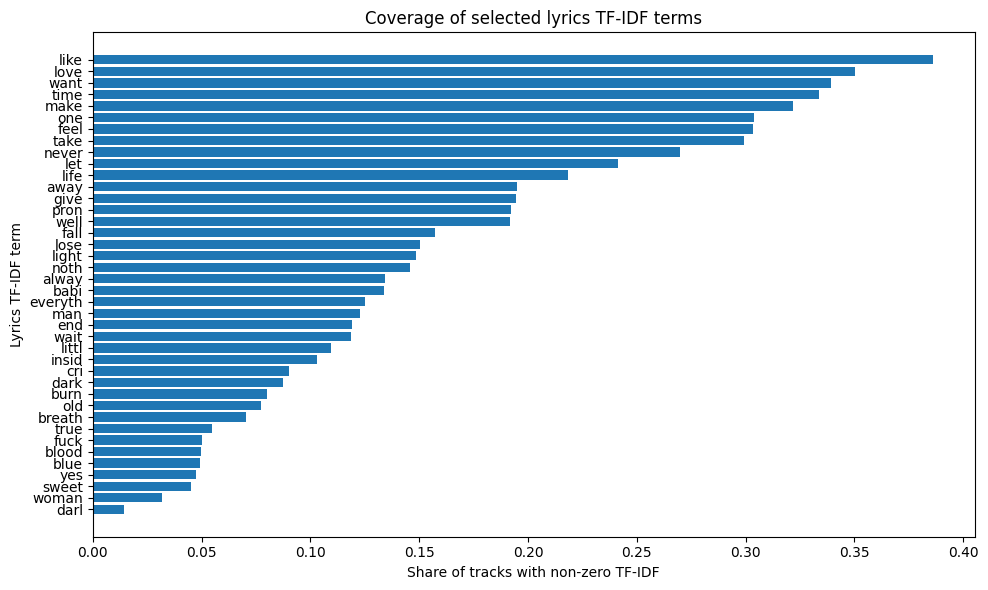

In [49]:
plt.figure(figsize=(10, 6))

plot_data = selected_coverage.sort_values("nonzero_share", ascending=True)

plt.barh(
    plot_data["feature"],
    plot_data["nonzero_share"],
)

plt.xlabel("Share of tracks with non-zero TF-IDF")
plt.ylabel("Lyrics TF-IDF term")
plt.title("Coverage of selected lyrics TF-IDF terms")
plt.tight_layout()

output_path = PLOTS_DIR / "lyrics_tfidf_selected_term_coverage.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## 5. Dataset-Level Raw TF-IDF Trajectories

Plot average TF-IDF trajectories across all selected tracks and genres.

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_love_trajectory.png


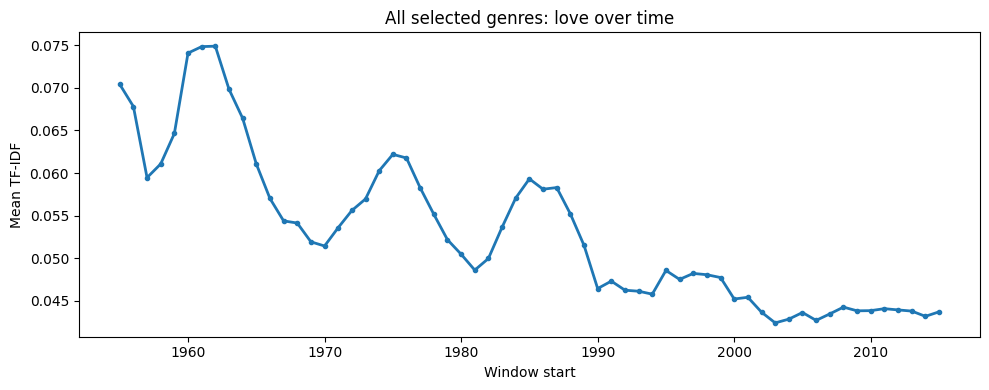

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_babi_trajectory.png


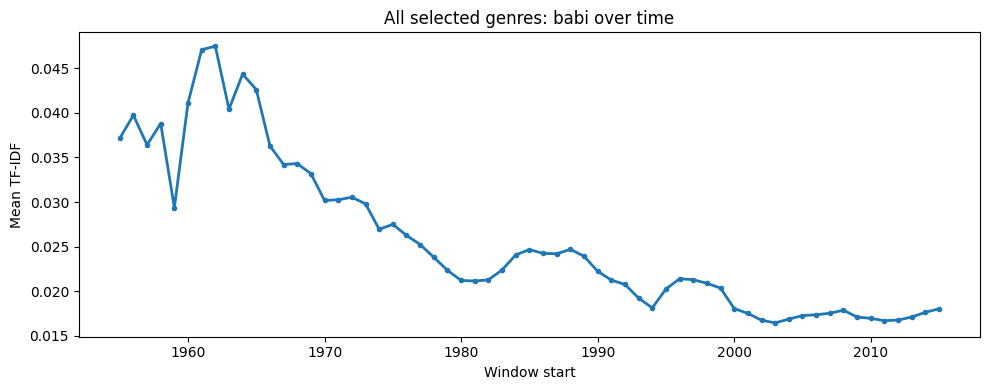

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_want_trajectory.png


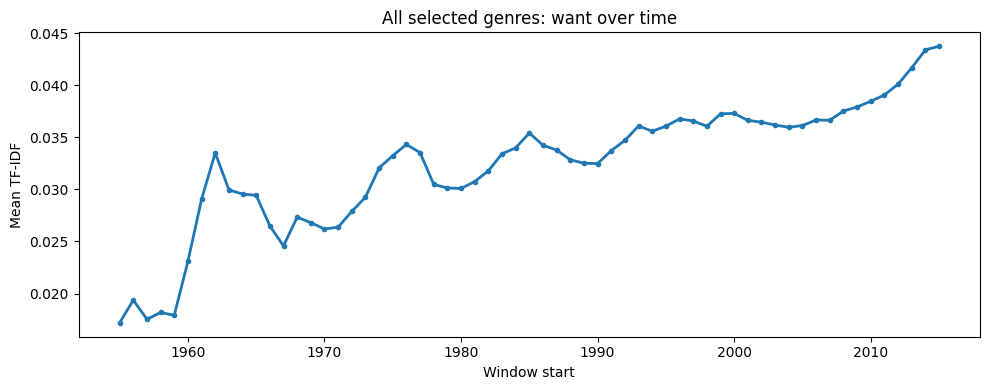

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_blue_trajectory.png


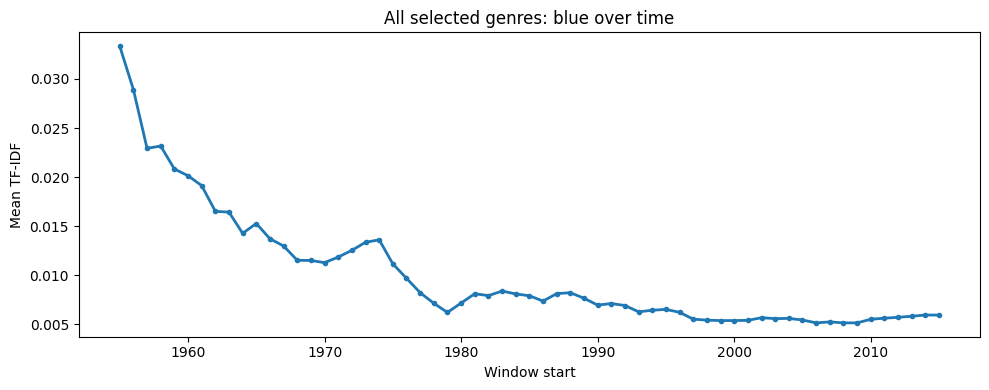

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_feel_trajectory.png


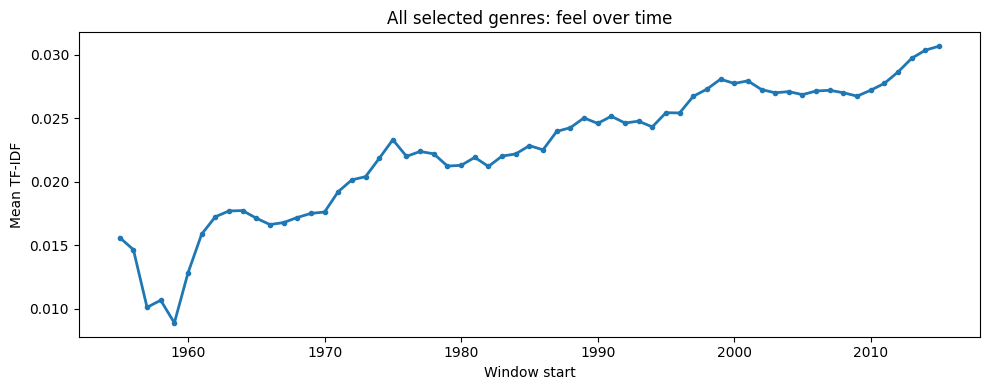

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_man_trajectory.png


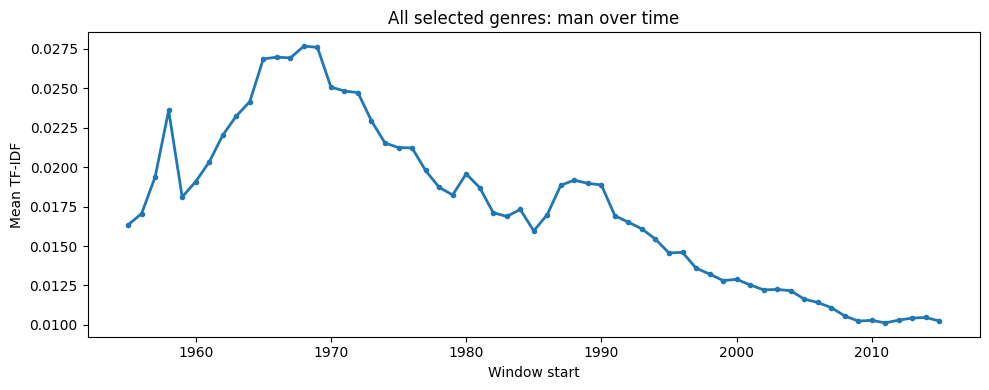

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_well_trajectory.png


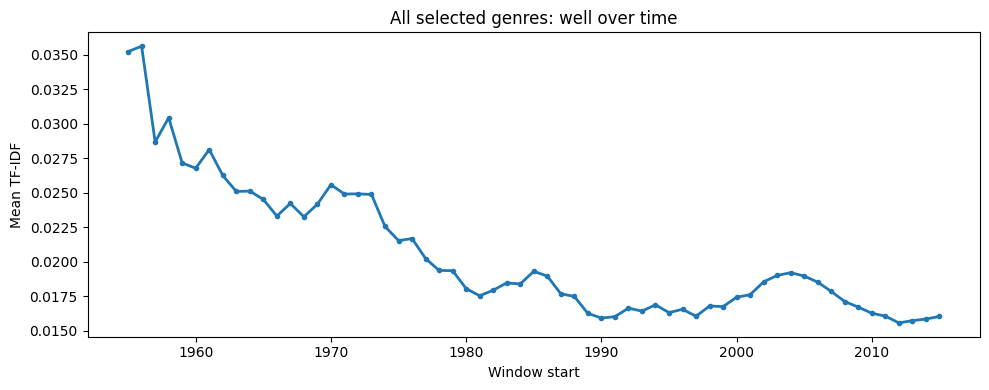

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_like_trajectory.png


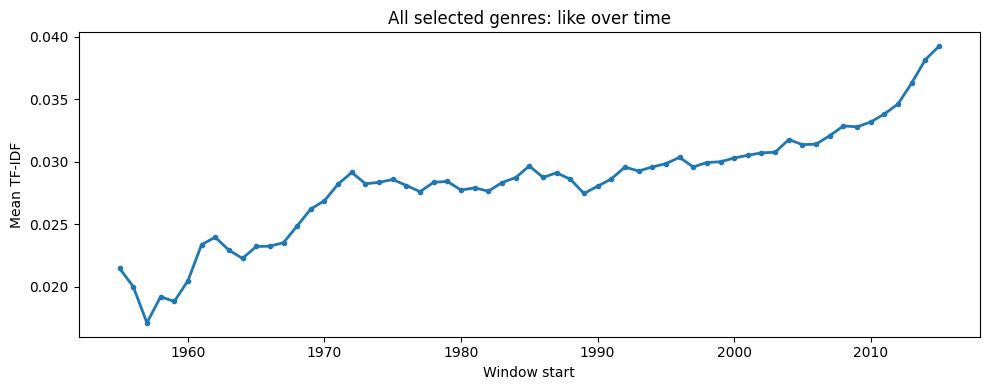

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_pron_trajectory.png


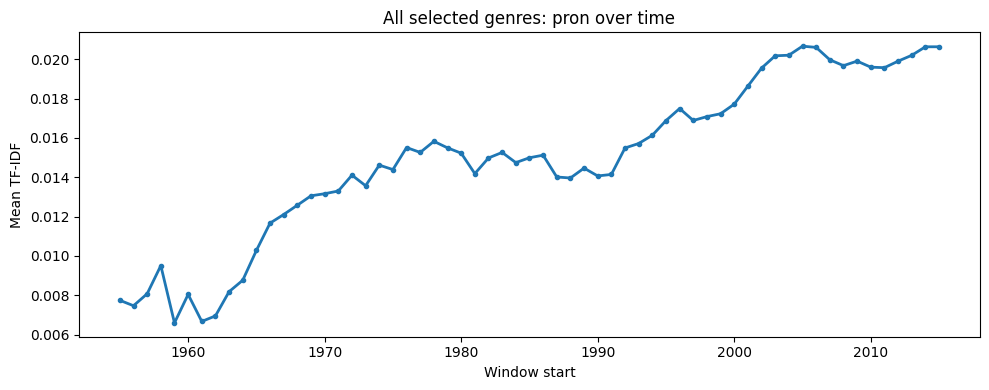

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_all_genres_cri_trajectory.png


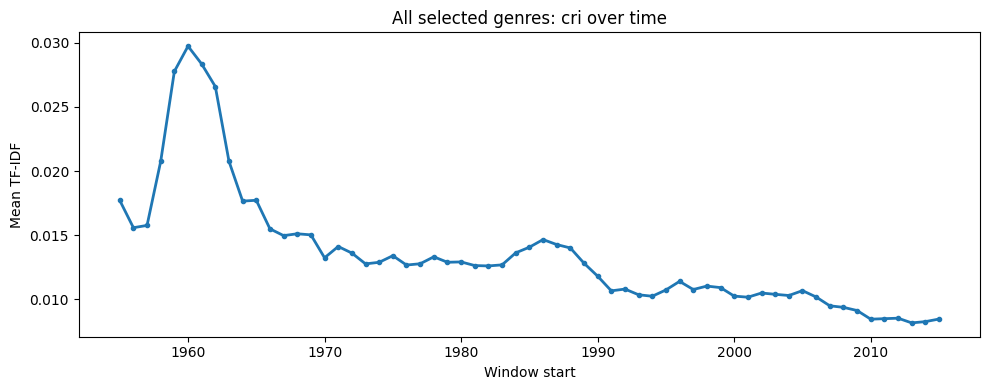

In [50]:
def plot_all_genres_term_trajectory(feature: str) -> None:
    plt.figure(figsize=(10, 4))

    plt.plot(
        all_genres_window_summary["window_start"],
        all_genres_window_summary[feature],
        marker="o",
        markersize=3,
        linewidth=2,
    )

    plt.xlabel("Window start")
    plt.ylabel("Mean TF-IDF")
    plt.title(f"All selected genres: {feature} over time")
    plt.tight_layout()

    safe_feature = str(feature).replace("/", "_").replace(" ", "_")
    output_path = PLOTS_DIR / f"lyrics_tfidf_all_genres_{safe_feature}_trajectory.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(output_path)

    plt.show()


for feature in selected_feature_terms[:10]:
    plot_all_genres_term_trajectory(feature)

## 6. Strongest Dataset-Level Increasing And Decreasing Terms

Rank selected terms by their linear trend across all selected tracks.

In [51]:
change_overview = all_genres_feature_change.sort_values(
    "linear_trend",
    ascending=False,
)

change_overview[
    [
        "feature",
        "first_window_value",
        "last_window_value",
        "last_minus_first",
        "linear_trend",
        "mean_value",
    ]
]

,feature,first_window_value,last_window_value,last_minus_first,linear_trend,mean_value
2,want,0.017189,0.043742,0.026552,0.000308,0.032314
4,feel,0.015614,0.030688,0.015074,0.000277,0.022418
7,like,0.021465,0.039253,0.017789,0.000230,0.028219
8,pron,0.007741,0.020640,0.012899,0.000217,0.014899
12,life,0.008042,0.019440,0.011397,0.000182,0.018905
13,let,0.017312,0.027006,0.009694,0.000178,0.020626
14,light,0.003750,0.015942,0.012192,0.000176,0.011247
15,breath,0.000282,0.008936,0.008653,0.000169,0.004898
16,insid,0.003152,0.009720,0.006568,0.000164,0.008596
17,everyth,0.005667,0.014430,0.008763,0.000164,0.010245


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_top_increasing_decreasing_terms.png


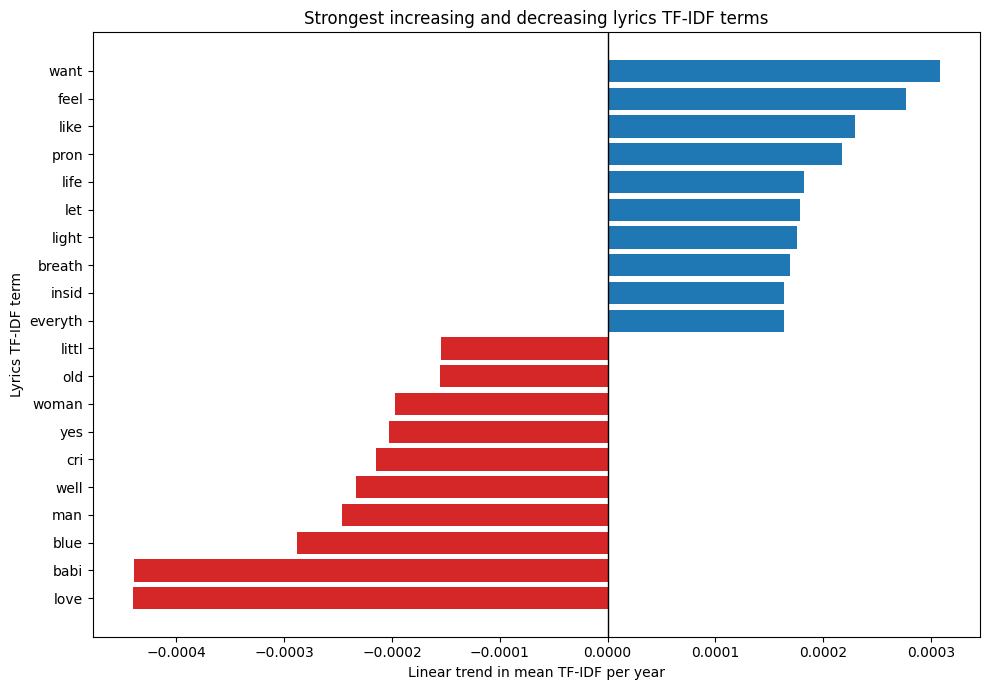

In [52]:
top_n = 10

increase_terms = all_genres_feature_change.nlargest(top_n, "linear_trend")
decrease_terms = all_genres_feature_change.nsmallest(top_n, "linear_trend")
plot_data = pd.concat([decrease_terms, increase_terms], ignore_index=True)
plot_data = plot_data.drop_duplicates(subset=["feature"]).sort_values("linear_trend")

plt.figure(figsize=(10, 7))

colors = np.where(plot_data["linear_trend"] >= 0, "tab:blue", "tab:red")

plt.barh(
    plot_data["feature"],
    plot_data["linear_trend"],
    color=colors,
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Linear trend in mean TF-IDF per year")
plt.ylabel("Lyrics TF-IDF term")
plt.title("Strongest increasing and decreasing lyrics TF-IDF terms")
plt.tight_layout()

output_path = PLOTS_DIR / "lyrics_tfidf_top_increasing_decreasing_terms.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## 7. Compare Multiple Term Trajectories

Plot selected increasing and decreasing terms in one figure.

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_selected_term_trajectories.png


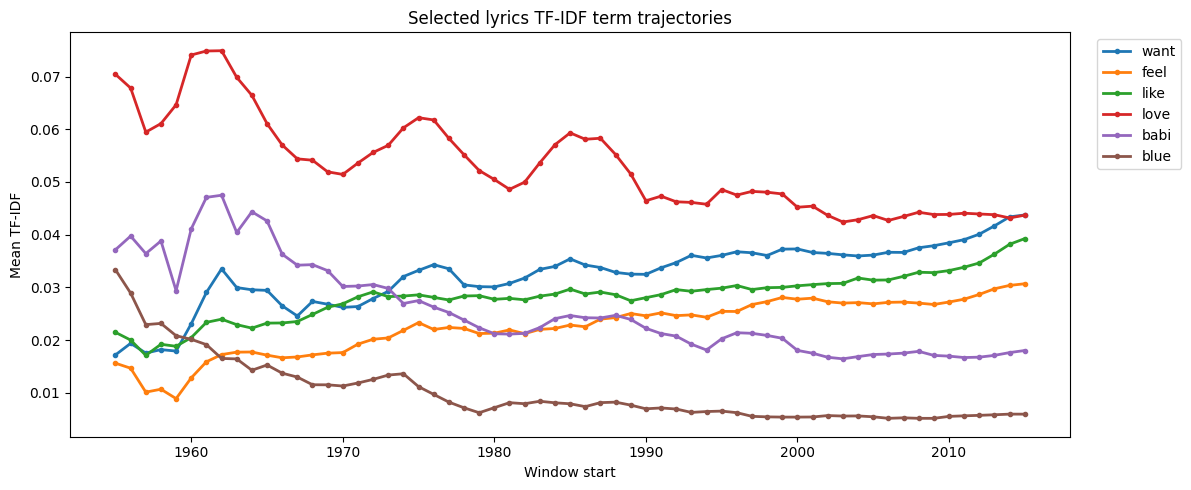

In [53]:
terms_to_compare = (
    all_genres_feature_change.nlargest(3, "linear_trend")["feature"].tolist()
    + all_genres_feature_change.nsmallest(3, "linear_trend")["feature"].tolist()
)
terms_to_compare = list(dict.fromkeys(terms_to_compare))

plt.figure(figsize=(12, 5))

for feature in terms_to_compare:
    plt.plot(
        all_genres_window_summary["window_start"],
        all_genres_window_summary[feature],
        marker="o",
        markersize=3,
        linewidth=2,
        label=feature,
    )

plt.xlabel("Window start")
plt.ylabel("Mean TF-IDF")
plt.title("Selected lyrics TF-IDF term trajectories")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

output_path = PLOTS_DIR / "lyrics_tfidf_selected_term_trajectories.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## 8. Genre-Level Trends For One Selected Term

Choose one term and show the strongest increasing/decreasing genres.

In [54]:
selected_feature = all_genres_feature_change.nlargest(1, "linear_trend")["feature"].iloc[0]
selected_feature

'want'

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_genre_trend_extremes_want.png


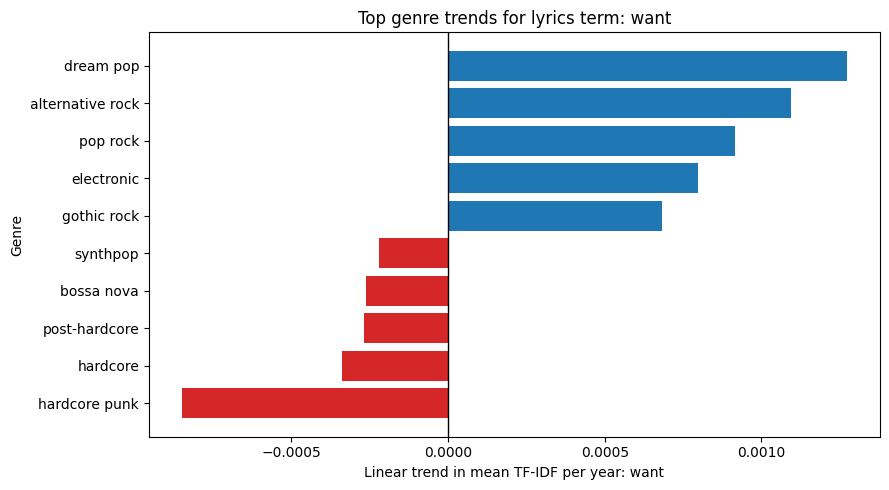

In [55]:
feature_genre_trends = genre_feature_trends[
    genre_feature_trends["feature"] == selected_feature
].dropna(subset=["linear_trend"]).copy()

top_n = 5
increase_genres = feature_genre_trends.nlargest(top_n, "linear_trend")
decrease_genres = feature_genre_trends.nsmallest(top_n, "linear_trend")
plot_data = pd.concat([decrease_genres, increase_genres], ignore_index=True)
plot_data = plot_data.drop_duplicates(subset=["genre"]).sort_values("linear_trend")

plt.figure(figsize=(9, 5))

colors = np.where(plot_data["linear_trend"] >= 0, "tab:blue", "tab:red")

plt.barh(
    plot_data["genre"],
    plot_data["linear_trend"],
    color=colors,
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel(f"Linear trend in mean TF-IDF per year: {selected_feature}")
plt.ylabel("Genre")
plt.title(f"Top genre trends for lyrics term: {selected_feature}")
plt.tight_layout()

safe_feature = str(selected_feature).replace("/", "_").replace(" ", "_")
output_path = PLOTS_DIR / f"lyrics_tfidf_genre_trend_extremes_{safe_feature}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## 9. Genre Versus Dataset Reference For One Term

Plot selected genres against the all-selected-track reference trajectory.

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_genres_vs_reference_want.png


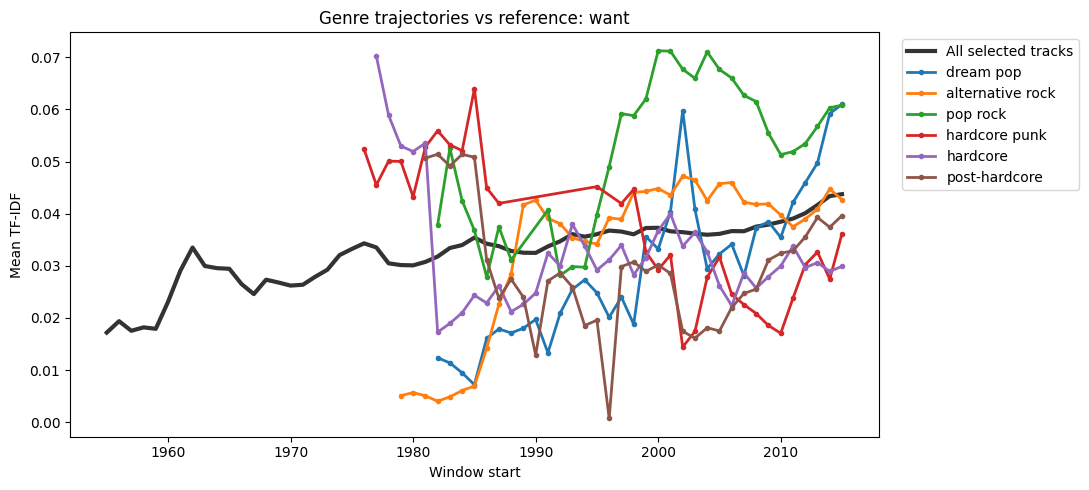

In [56]:
genres_to_compare = (
    increase_genres.head(3)["genre"].tolist()
    + decrease_genres.head(3)["genre"].tolist()
)
genres_to_compare = list(dict.fromkeys(genres_to_compare))

plt.figure(figsize=(11, 5))

plt.plot(
    all_genres_window_summary["window_start"],
    all_genres_window_summary[selected_feature],
    color="black",
    linewidth=3,
    alpha=0.8,
    label="All selected tracks",
)

for genre in genres_to_compare:
    genre_data = eligible_genre_window_summary[
        eligible_genre_window_summary["genre"] == genre
    ].sort_values("window_start")

    plt.plot(
        genre_data["window_start"],
        genre_data[selected_feature],
        marker="o",
        markersize=3,
        linewidth=2,
        label=genre,
    )

plt.xlabel("Window start")
plt.ylabel("Mean TF-IDF")
plt.title(f"Genre trajectories vs reference: {selected_feature}")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

output_path = PLOTS_DIR / f"lyrics_tfidf_genres_vs_reference_{safe_feature}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## 10. Within-Period Normalized Genre Positions

Show how genres are positioned relative to the same-period selected-track distribution.

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_within_period_z_heatmap_want.png


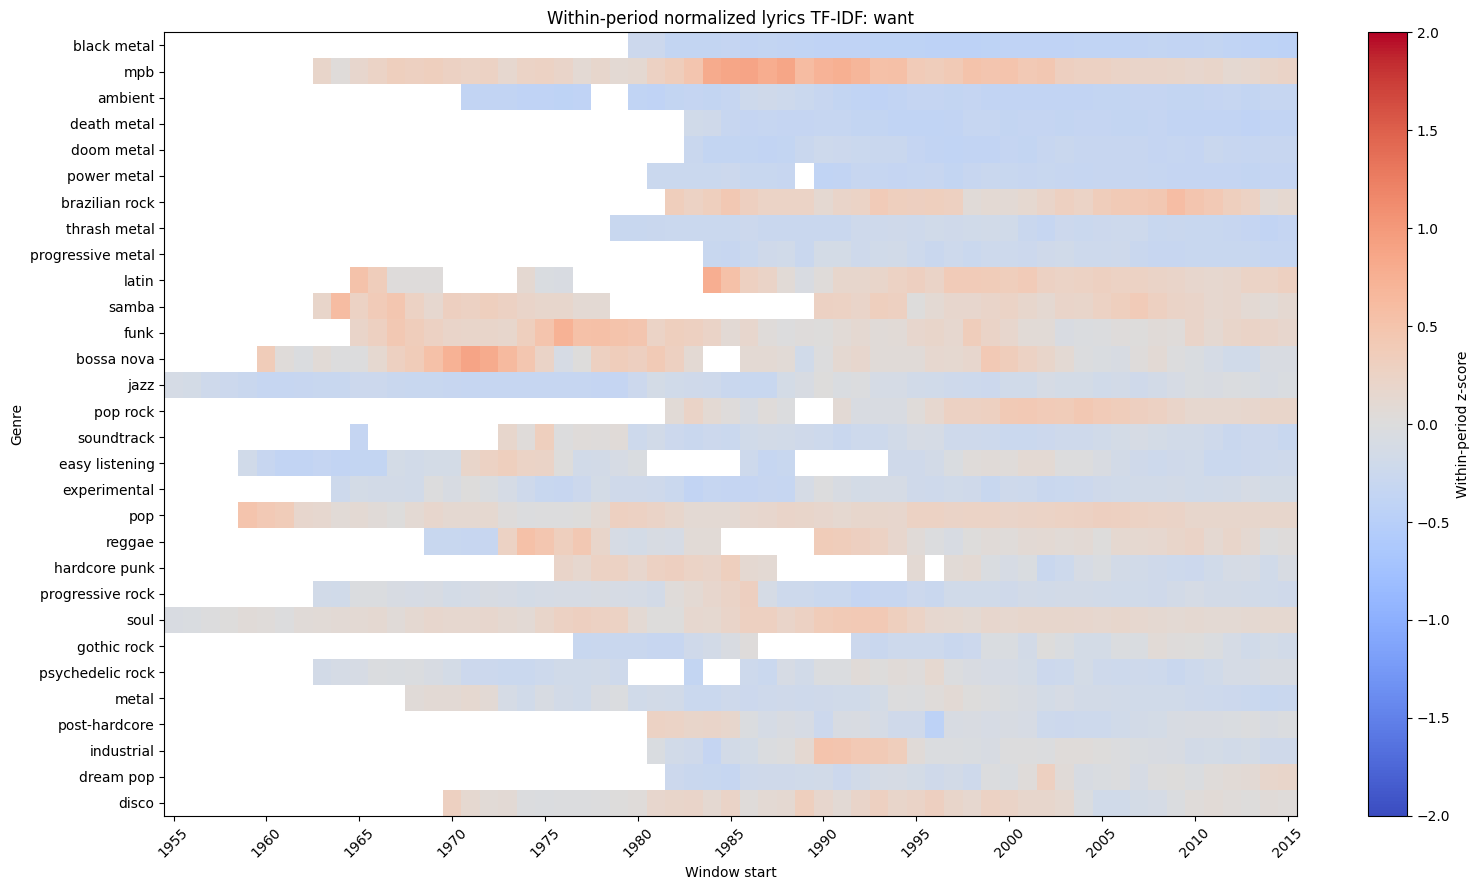

In [57]:
selected_z_feature = selected_feature
n_top_genres = 30

stable_genres = (
    feature_deviation_summary[
        feature_deviation_summary["feature"] == selected_z_feature
    ]
    .sort_values(
        ["mean_absolute_relative_position", "n_valid_windows"],
        ascending=[False, False],
    )
    .head(n_top_genres)["genre"]
    .tolist()
)

matrix_data = eligible_genre_window_z_summary.copy()

matrix_data = matrix_data[
    matrix_data["genre"].isin(stable_genres)
].pivot_table(
    index="genre",
    columns="window_start",
    values=selected_z_feature,
    aggfunc="mean",
)

matrix_data = matrix_data.reindex(stable_genres)

plt.figure(figsize=(16, 9))

plt.imshow(
    matrix_data,
    aspect="auto",
    cmap="coolwarm",
    vmin=-2,
    vmax=2,
)

plt.yticks(range(len(matrix_data.index)), matrix_data.index)
plt.xticks(
    range(0, len(matrix_data.columns), 5),
    matrix_data.columns[::5],
    rotation=45,
)

plt.xlabel("Window start")
plt.ylabel("Genre")
plt.title(f"Within-period normalized lyrics TF-IDF: {selected_z_feature}")
plt.colorbar(label="Within-period z-score")
plt.tight_layout()

safe_feature = str(selected_z_feature).replace("/", "_").replace(" ", "_")
output_path = PLOTS_DIR / f"lyrics_tfidf_within_period_z_heatmap_{safe_feature}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## 11. Strongest Relative Genre Deviations

Inspect genres that are most strongly above or below the same-period average for a selected term.

In [58]:
relative_deviation = feature_deviation_summary[
    feature_deviation_summary["feature"] == selected_z_feature
].copy()

relative_deviation.sort_values(
    "mean_absolute_relative_position",
    ascending=False,
)[
    [
        "feature",
        "genre",
        "n_valid_windows",
        "mean_relative_position",
        "median_relative_position",
        "mean_absolute_relative_position",
    ]
].head(20)

,feature,genre,n_valid_windows,mean_relative_position,median_relative_position,mean_absolute_relative_position
102,want,black metal,36,-0.379345,-0.386307,0.379345
128,want,mpb,53,0.360780,0.276930,0.360780
101,want,ambient,43,-0.345883,-0.350498,0.345883
108,want,death metal,33,-0.339303,-0.344828,0.339303
110,want,doom metal,33,-0.316067,-0.312188,0.316067
134,want,power metal,34,-0.311187,-0.311451,0.311187
105,want,brazilian rock,34,0.281544,0.289997,0.281544
149,want,thrash metal,37,-0.256629,-0.264894,0.256629
135,want,progressive metal,32,-0.242388,-0.242063,0.242388
126,want,latin,40,0.231670,0.240882,0.241579


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_relative_genre_positions_want.png


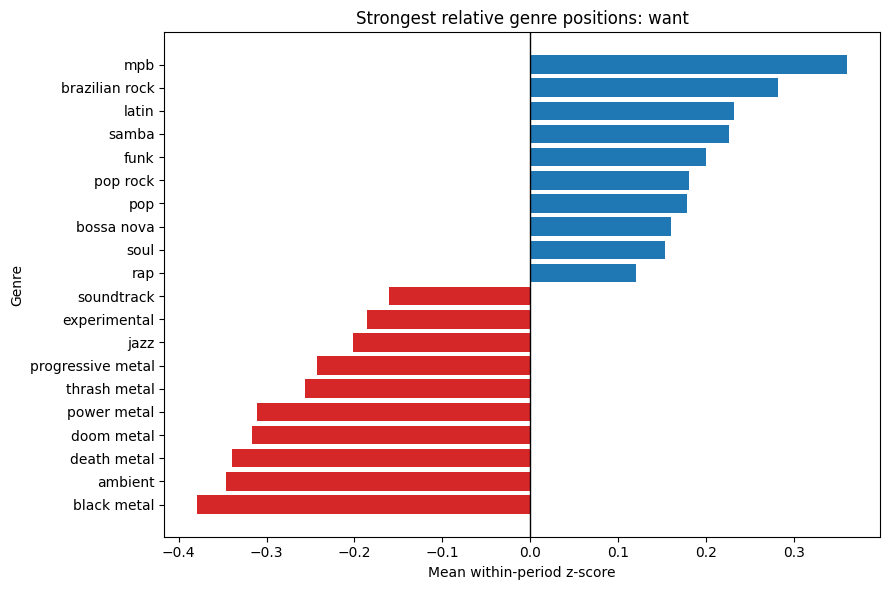

In [59]:
top_positive = relative_deviation.nlargest(10, "mean_relative_position")
top_negative = relative_deviation.nsmallest(10, "mean_relative_position")
plot_data = pd.concat([top_negative, top_positive], ignore_index=True)
plot_data = plot_data.drop_duplicates(subset=["genre"]).sort_values("mean_relative_position")

plt.figure(figsize=(9, 6))

colors = np.where(plot_data["mean_relative_position"] >= 0, "tab:blue", "tab:red")

plt.barh(
    plot_data["genre"],
    plot_data["mean_relative_position"],
    color=colors,
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Mean within-period z-score")
plt.ylabel("Genre")
plt.title(f"Strongest relative genre positions: {selected_z_feature}")
plt.tight_layout()

output_path = PLOTS_DIR / f"lyrics_tfidf_relative_genre_positions_{safe_feature}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## 12. Raw And Normalized View For One Genre-Term Pair

Show the raw TF-IDF trajectory and the corresponding within-period normalized trajectory.

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_raw_and_z_black_metal_want.png


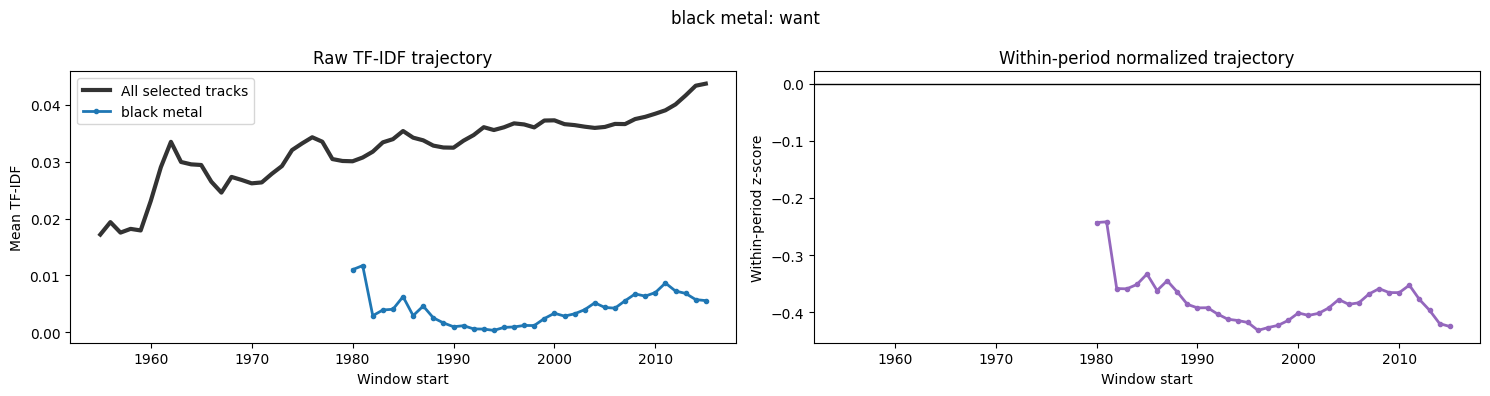

In [60]:
selected_genre = relative_deviation.nlargest(
    1,
    "mean_absolute_relative_position",
)["genre"].iloc[0]

raw_genre_data = eligible_genre_window_summary[
    eligible_genre_window_summary["genre"] == selected_genre
].sort_values("window_start")

z_genre_data = eligible_genre_window_z_summary[
    eligible_genre_window_z_summary["genre"] == selected_genre
].sort_values("window_start")

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=True)

axes[0].plot(
    all_genres_window_summary["window_start"],
    all_genres_window_summary[selected_z_feature],
    color="black",
    linewidth=3,
    alpha=0.8,
    label="All selected tracks",
)

axes[0].plot(
    raw_genre_data["window_start"],
    raw_genre_data[selected_z_feature],
    marker="o",
    markersize=3,
    linewidth=2,
    label=selected_genre,
)

axes[0].set_title("Raw TF-IDF trajectory")
axes[0].set_xlabel("Window start")
axes[0].set_ylabel("Mean TF-IDF")
axes[0].legend()

axes[1].plot(
    z_genre_data["window_start"],
    z_genre_data[selected_z_feature],
    marker="o",
    markersize=3,
    linewidth=2,
    color="tab:purple",
)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Within-period normalized trajectory")
axes[1].set_xlabel("Window start")
axes[1].set_ylabel("Within-period z-score")

fig.suptitle(f"{selected_genre}: {selected_z_feature}")
plt.tight_layout()

safe_genre = str(selected_genre).replace("/", "_").replace(" ", "_")
output_path = PLOTS_DIR / f"lyrics_tfidf_raw_and_z_{safe_genre}_{safe_feature}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## 13. Save Compact Overview Tables

Optional compact tables for later reporting.

In [61]:
compact_term_overview = selected_features.merge(
    all_genres_feature_change,
    on="feature",
    how="left",
    suffixes=("_selection", "_change"),
)

compact_term_overview.to_csv(
    PLOTS_DIR / "lyrics_tfidf_selected_term_overview.csv",
    index=False,
)

compact_term_overview.head(20)

,feature,n_tracks,n_nonzero_tracks,n_zero_tracks,nonzero_share,mean_tfidf,std_tfidf,mean_nonzero_tfidf,median_nonzero_tfidf,max_tfidf,...,absolute_last_minus_first,linear_trend_selection,absolute_linear_trend,selection_rank,first_window_value_change,last_window_value_change,last_minus_first_change,linear_trend_change,mean_value,median_value
0,love,97883,34299,63584,0.350408,0.046203,0.102540,0.131856,0.082077,0.997476,...,0.026723,-0.000440,0.000440,1,0.070421,0.043698,-0.026723,-0.000440,0.053172,0.051512
1,babi,97883,13113,84770,0.133966,0.019474,0.071580,0.145365,0.093062,0.994882,...,0.019128,-0.000439,0.000439,2,0.037149,0.018021,-0.019128,-0.000439,0.025715,0.022377
2,want,97883,33190,64693,0.339078,0.038134,0.085454,0.112463,0.071786,0.990882,...,0.026552,0.000308,0.000308,3,0.017189,0.043742,0.026552,0.000308,0.032314,0.033526
3,blue,97883,4835,93048,0.049396,0.006501,0.040172,0.131619,0.090917,0.971509,...,0.027392,-0.000288,0.000288,4,0.033337,0.005946,-0.027392,-0.000288,0.010099,0.007658
4,feel,97883,29703,68180,0.303454,0.027121,0.062904,0.089374,0.060279,1.000000,...,0.015074,0.000277,0.000277,5,0.015614,0.030688,0.015074,0.000277,0.022418,0.022853
5,man,97883,12031,85852,0.122912,0.012826,0.049859,0.104351,0.070697,0.980736,...,0.006101,-0.000246,0.000246,6,0.016345,0.010245,-0.006101,-0.000246,0.017522,0.017122
6,well,97883,18783,79100,0.191892,0.017480,0.052444,0.091094,0.062162,0.973588,...,0.019171,-0.000233,0.000233,7,0.035225,0.016054,-0.019171,-0.000233,0.020568,0.018560
7,like,97883,37780,60103,0.385971,0.033263,0.065379,0.086179,0.059665,0.900476,...,0.017789,0.000230,0.000230,8,0.021465,0.039253,0.017789,0.000230,0.028219,0.028607
8,pron,97883,18813,79070,0.192199,0.018654,0.054603,0.097053,0.066590,0.858412,...,0.012899,0.000217,0.000217,9,0.007741,0.020640,0.012899,0.000217,0.014899,0.015125
9,cri,97883,8806,89077,0.089965,0.010095,0.046084,0.112207,0.077792,0.982930,...,0.009248,-0.000215,0.000215,10,0.017716,0.008468,-0.009248,-0.000215,0.013518,0.012767


In [62]:
selected_term = "feel"
n_top_genres = 3

term_data = eligible_genre_window_summary[
    ["genre", "window_start", selected_term]
].dropna().copy()

slope_rows = []

for genre, genre_data in term_data.groupby("genre"):
    genre_data = genre_data.sort_values("window_start")

    if genre_data["window_start"].nunique() < 2:
        continue

    slope, intercept = np.polyfit(
        genre_data["window_start"],
        genre_data[selected_term],
        deg=1,
    )

    slope_rows.append({
        "genre": genre,
        "slope": slope,
        "first_window": genre_data["window_start"].min(),
        "last_window": genre_data["window_start"].max(),
        "first_value": genre_data.iloc[0][selected_term],
        "last_value": genre_data.iloc[-1][selected_term],
        "last_minus_first": (
            genre_data.iloc[-1][selected_term]
            - genre_data.iloc[0][selected_term]
        ),
        "n_valid_windows": genre_data["window_start"].nunique(),
    })

term_genre_trends = pd.DataFrame(slope_rows)

top_increasing_genres = (
    term_genre_trends
    .sort_values("slope", ascending=False)
    .head(n_top_genres)["genre"]
    .tolist()
)

top_decreasing_genres = (
    term_genre_trends
    .sort_values("slope", ascending=True)
    .head(n_top_genres)["genre"]
    .tolist()
)

selected_genres = top_increasing_genres + top_decreasing_genres

term_genre_trends[
    term_genre_trends["genre"].isin(selected_genres)
].sort_values("slope", ascending=False)

,genre,slope,first_window,last_window,first_value,last_value,last_minus_first,n_valid_windows
0,alternative rock,0.000876,1979,2015,0.011698,0.036117,0.024419,37
13,electronic,0.000752,1971,2015,0.009098,0.031692,0.022595,45
19,grunge,0.000751,1984,2015,0.034221,0.047774,0.013553,32
45,soft rock,-0.000239,1967,2015,0.052521,0.033468,-0.019053,49
43,shoegaze,-0.000243,1981,2015,0.023044,0.037059,0.014014,35
35,progressive metal,-0.000473,1984,2015,0.029678,0.025520,-0.004158,32


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_feel_top3_genre_trends_vs_reference.png


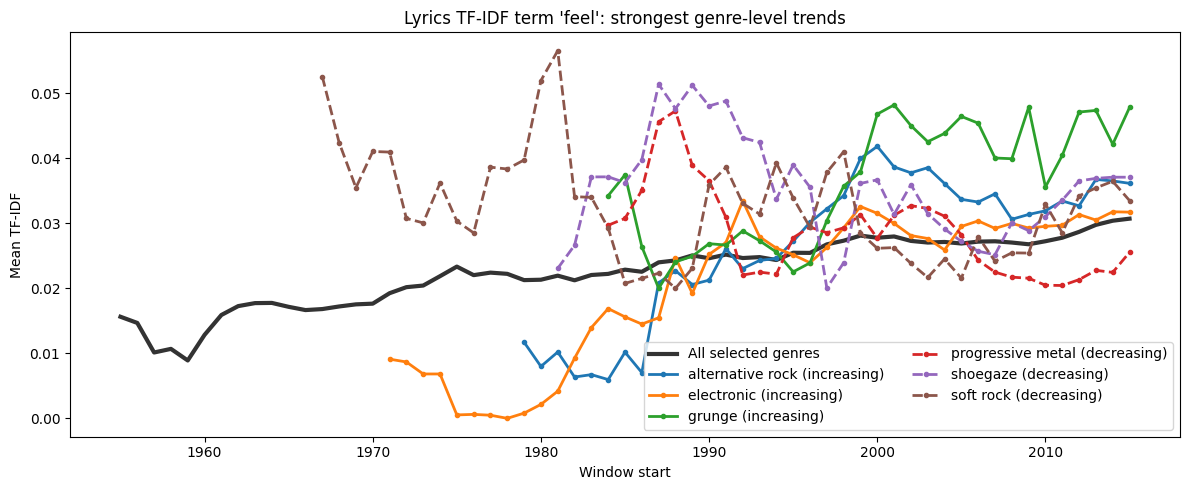

In [63]:
plt.figure(figsize=(12, 5))

plt.plot(
    all_genres_window_summary["window_start"],
    all_genres_window_summary[selected_term],
    color="black",
    linewidth=3,
    alpha=0.8,
    label="All selected genres",
)

for genre in top_increasing_genres:
    genre_data = (
        term_data[term_data["genre"] == genre]
        .sort_values("window_start")
    )

    plt.plot(
        genre_data["window_start"],
        genre_data[selected_term],
        marker="o",
        markersize=3,
        linewidth=2,
        label=f"{genre} (increasing)",
    )

for genre in top_decreasing_genres:
    genre_data = (
        term_data[term_data["genre"] == genre]
        .sort_values("window_start")
    )

    plt.plot(
        genre_data["window_start"],
        genre_data[selected_term],
        marker="o",
        markersize=3,
        linewidth=2,
        linestyle="--",
        label=f"{genre} (decreasing)",
    )

plt.xlabel("Window start")
plt.ylabel("Mean TF-IDF")
plt.title(
    f"Lyrics TF-IDF term '{selected_term}': strongest genre-level trends"
)
plt.legend(ncol=2)
plt.tight_layout()

output_path = (
    PLOTS_DIR
    / f"lyrics_tfidf_{selected_term}_top{n_top_genres}_genre_trends_vs_reference.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

min_valid_windows = 30
max_first_window = 1975
min_last_window = 2010

def calculate_slope(data, x_col, y_col):
    slope_data = data[[x_col, y_col]].dropna().sort_values(x_col)

    if slope_data[x_col].nunique() < 2:
        return np.nan

    slope, _ = np.polyfit(
        slope_data[x_col],
        slope_data[y_col],
        deg=1,
    )

    return slope


def get_stable_extreme_genres_for_term(term):
    genre_rows = []

    term_data = eligible_genre_window_summary[
        ["genre", "window_start", term]
    ].dropna().copy()

    for genre, genre_data in term_data.groupby("genre"):
        genre_data = genre_data.sort_values("window_start")

        n_valid_windows = genre_data["window_start"].nunique()
        first_window = genre_data["window_start"].min()
        last_window = genre_data["window_start"].max()

        if n_valid_windows < min_valid_windows:
            continue

        if first_window > max_first_window:
            continue

        if last_window < min_last_window:
            continue

        slope = calculate_slope(
            data=genre_data,
            x_col="window_start",
            y_col=term,
        )

        genre_rows.append({
            "genre": genre,
            "slope": slope,
            "n_valid_windows": n_valid_windows,
            "first_window": first_window,
            "last_window": last_window,
            "first_value": genre_data.iloc[0][term],
            "last_value": genre_data.iloc[-1][term],
            "last_minus_first": genre_data.iloc[-1][term] - genre_data.iloc[0][term],
        })

    genre_slopes = pd.DataFrame(genre_rows).dropna()

    highest_increase_genre = (
        genre_slopes
        .sort_values("slope", ascending=False)
        .iloc[0]["genre"]
    )

    highest_decrease_genre = (
        genre_slopes
        .sort_values("slope", ascending=True)
        .iloc[0]["genre"]
    )

    return highest_increase_genre, highest_decrease_genre, genre_slopes

In [65]:
def plot_term_with_stable_extreme_genres(term, output_suffix):
    highest_increase_genre, highest_decrease_genre, genre_slopes = (
        get_stable_extreme_genres_for_term(term)
    )

    plt.figure(figsize=(11, 5))

    plt.plot(
        all_genres_window_summary["window_start"],
        all_genres_window_summary[term],
        color="black",
        linewidth=3,
        alpha=0.8,
        label="All selected genres",
    )

    increase_data = (
        eligible_genre_window_summary[
            eligible_genre_window_summary["genre"] == highest_increase_genre
        ]
        .sort_values("window_start")
    )

    decrease_data = (
        eligible_genre_window_summary[
            eligible_genre_window_summary["genre"] == highest_decrease_genre
        ]
        .sort_values("window_start")
    )

    plt.plot(
        increase_data["window_start"],
        increase_data[term],
        marker="o",
        markersize=3,
        linewidth=2,
        color="tab:blue",
        label=f"Highest stable increase: {highest_increase_genre}",
    )

    plt.plot(
        decrease_data["window_start"],
        decrease_data[term],
        marker="o",
        markersize=3,
        linewidth=2,
        linestyle="--",
        color="tab:red",
        label=f"Highest stable decrease: {highest_decrease_genre}",
    )

    plt.xlabel("Window start")
    plt.ylabel("Mean TF-IDF")
    plt.title(
        f"Lyrics TF-IDF term '{term}': stable genre-level contrast"
    )
    plt.legend()
    plt.tight_layout()

    output_path = (
        PLOTS_DIR
        / f"lyrics_tfidf_{output_suffix}_{term}_stable_genre_extremes_vs_reference.png"
    )

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(output_path)

    plt.show()

    display(
        genre_slopes[
            genre_slopes["genre"].isin(
                [highest_increase_genre, highest_decrease_genre]
            )
        ].sort_values("slope", ascending=False)
    )

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_lyrics_tfidf/lyrics_tfidf_selected_term_like_stable_genre_extremes_vs_reference.png


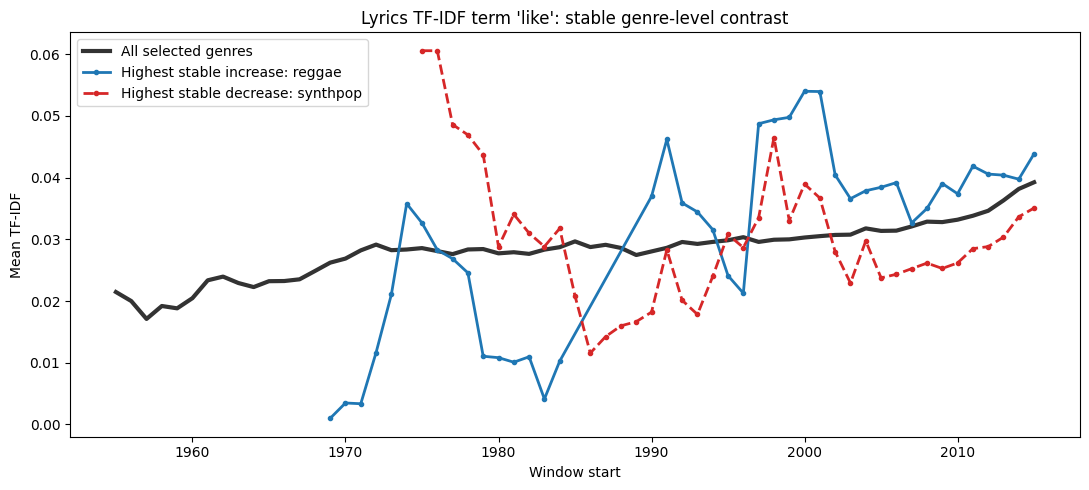

,genre,slope,n_valid_windows,first_window,last_window,first_value,last_value,last_minus_first
23,reggae,0.000753,42,1969,2015,0.000995,0.043870,0.042875
30,synthpop,-0.000269,41,1975,2015,0.060570,0.035076,-0.025494


In [66]:
selected_term = "like"

plot_term_with_stable_extreme_genres(
    term=selected_term,
    output_suffix="selected_term",
)